In [1]:
!pip install tensorflow opencv-python-headless scikit-learn matplotlib seaborn pandas numpy

In [2]:
# Import all libraries we will use  

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    Flatten, BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Define paths – THIS IS THE MOST IMPORTANT CELL TO CHANGE   
# You **must** update DATASET_ROOT to point to where you extracted FER2013

# Examples – change to match your computer
DATASET_ROOT = r"C:\Users\Lfellous\Desktop\FER2013"           # Windows example
# DATASET_ROOT = "/home/yourusername/datasets/FER2013"          # Linux / macOS example

train_dir = os.path.join(DATASET_ROOT, "train")
val_dir   = os.path.join(DATASET_ROOT, "test")                  # sometimes called "validation" or "PrivateTest"

# Where to save model weights and result plots
SAVE_DIR = r"C:\Users\Lfellous\Desktop\FER2013_results"       # ← change if desired
os.makedirs(SAVE_DIR, exist_ok=True)

WEIGHTS_OUT = os.path.join(SAVE_DIR, "emotion_model.weights.h5")
PLOT_CURVES = os.path.join(SAVE_DIR, "training_curves.png")
CONF_MATRIX = os.path.join(SAVE_DIR, "confusion_matrix.png")

print("Expecting dataset structure here:")
print("  Train folder →", train_dir)
print("  Val folder   →", val_dir)
print("Results will be saved to →", SAVE_DIR)

Expecting dataset structure here:
  Train folder → C:\Users\Lfellous\Desktop\FER2013\train
  Val folder   → C:\Users\Lfellous\Desktop\FER2013\test
Results will be saved to → C:\Users\Lfellous\Desktop\FER2013_results


In [4]:
# Verify that the dataset folders exist and count images  
# Helps catch mistakes early (wrong path, missing subfolders, empty classes, etc.)

print("=== Dataset structure check ===\n")

for name, folder in [("Training", train_dir), ("Validation", val_dir)]:
    if not os.path.exists(folder):
        print(f"ERROR: Folder not found → {folder}")
        print("→ Please check / correct the DATASET_ROOT path in the previous cell")
        break
    
    print(f"{name} set:")
    total = 0
    for emotion in sorted(os.listdir(folder)):
        p = os.path.join(folder, emotion)
        if os.path.isdir(p):
            cnt = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])
            total += cnt
            print(f"  {emotion:12s} : {cnt:5d} images")
    print(f"  TOTAL images : {total:5d}\n")

=== Dataset structure check ===

Training set:
  angry        :  3995 images
  disgust      :   436 images
  fear         :  4097 images
  happy        :  7215 images
  neutral      :  4965 images
  sad          :  4830 images
  surprise     :  3171 images
  TOTAL images : 28709

Validation set:
  angry        :   958 images
  disgust      :   111 images
  fear         :  1024 images
  happy        :  1774 images
  neutral      :  1233 images
  sad          :  1247 images
  surprise     :   831 images
  TOTAL images :  7178



In [5]:
# Create data generators with data augmentation (only for training)  
# Augmentation improves generalization – especially useful on FER2013

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation: only rescaling – no random changes
val_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 32     # smaller value = less memory pressure (recommended on laptop)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes / labels mapping:", train_gen.class_indices)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes / labels mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [6]:
# Calculate class weights to handle strong class imbalance  
# disgust class has very few samples → weights help prevent the model ignoring it

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights (higher value = class gets more attention):")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls:2d} → weight {weight:.3f}")

Class weights (higher value = class gets more attention):
  Class  0 → weight 1.027
  Class  1 → weight 9.407
  Class  2 → weight 1.001
  Class  3 → weight 0.568
  Class  4 → weight 0.826
  Class  5 → weight 0.849
  Class  6 → weight 1.293


In [7]:
# Define the CNN model architecture  
# VGG-inspired structure adapted for small 48×48 grayscale images

model = Sequential([
    Input(shape=(48, 48, 1)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')   # 7 emotion classes
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,899,751 (7.25 MB)

 Trainable params: 1,897,319 (7.24 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [8]:
# Training callbacks – learning rate scheduling, early stopping, best model saving  

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=WEIGHTS_OUT, monitor='val_accuracy', save_best_only=True,
                    save_weights_only=True, verbose=1)
]

print("Callbacks configured – ready to start training")

Callbacks configured – ready to start training


In [9]:
# Start model training  
# This will take a long time on CPU – several hours total  
# You can reduce epochs to 20–30 for initial testing

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,                    # ← feel free to lower this number for testing
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print("\nTraining finished")
print(f"Best validation accuracy reached: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.1656 - loss: 2.4940
Epoch 1: val_accuracy improved from None to 0.22360, saving model to C:\Users\Lfellous\Desktop\FER2013_results\emotion_model.weights.h5

Epoch 1: finished saving model to C:\Users\Lfellous\Desktop\FER2013_results\emotion_model.weights.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 208s 225ms/step - accuracy: 0.1672 - loss: 2.2806 - val_accuracy: 0.2236 - val_loss: 1.8557 - learning_rate: 0.0010
Epoch 2/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.1930 - loss: 1.9364
Epoch 2: val_accuracy improved from 0.22360 to 0.25007, saving model to C:\Users\Lfellous\Desktop\FER2013_results\emotion_model.weights.h5

Epoch 2: finished saving model to C:\Users\Lfellous\Desktop\FER2013_results\emotion_model.weights.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 192s 214ms/step - accuracy: 0.2126 - loss: 1.8949 - val_accuracy: 0.2501 - val_loss: 1.8155 - learning_rate: 0.0010
Epoch 3/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step -

225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.6304 - loss: 1.0034
Test Loss: 1.0034
Test Accuracy: 0.6304
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step

Classification Report (validation set):
              precision    recall  f1-score   support

       Angry       0.58      0.51      0.54       958
     Disgust       0.32      0.81      0.46       111
        Fear       0.55      0.32      0.41      1024
       Happy       0.88      0.83      0.86      1774
     Neutral       0.52      0.71      0.60      1233
         Sad       0.53      0.45      0.48      1247
    Surprise       0.68      0.84      0.75       831

    accuracy                           0.63      7178
   macro avg       0.58      0.64      0.59      7178
weighted avg       0.64      0.63      0.62      7178



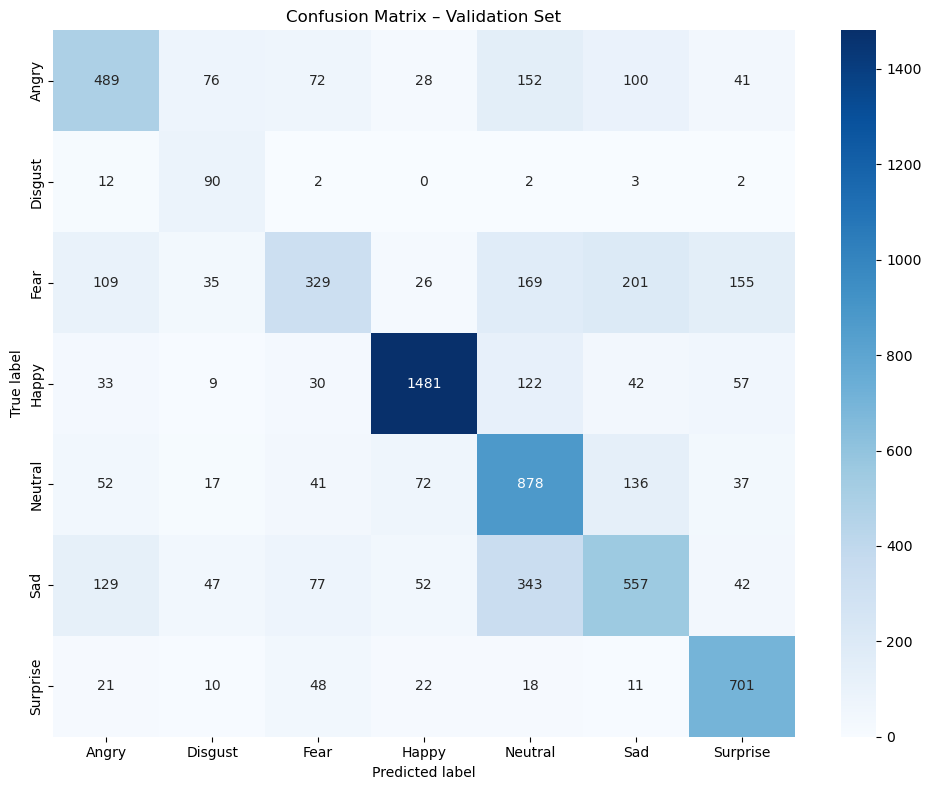

In [10]:
# ── Evaluate on validation set ───────────────────────────────────────────────
loss, accuracy = model.evaluate(val_gen)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# ── Predictions ──────────────────────────────────────────────────────────────
val_gen.reset()
predictions = model.predict(val_gen, verbose=1)
pred_labels = np.argmax(predictions, axis=1)
true_labels = val_gen.classes

emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

# ── Classification Report ────────────────────────────────────────────────────
print("\nClassification Report (validation set):")
print(classification_report(true_labels, pred_labels, target_names=emotion_names))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names)
plt.title('Confusion Matrix – Validation Set')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(CONF_MATRIX)
plt.show()

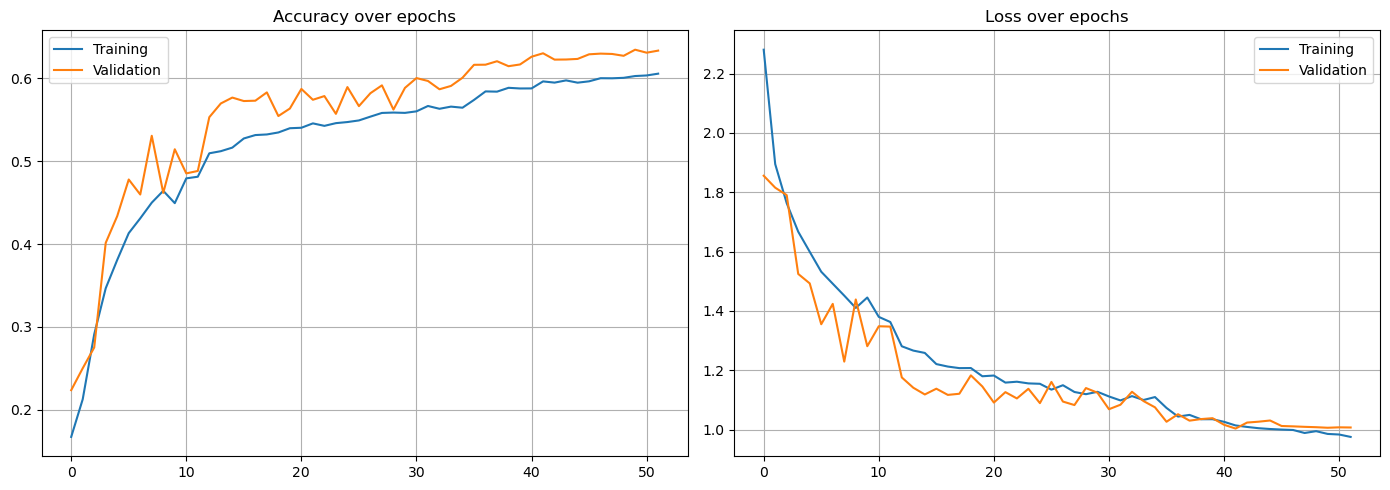

Training curves saved to: C:\Users\Lfellous\Desktop\FER2013_results\training_curves.png


In [11]:
# Plot training & validation accuracy and loss curves  

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over epochs')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over epochs')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(PLOT_CURVES)
plt.show()

print("Training curves saved to:", PLOT_CURVES)

Total misclassified: 2653 / 7178


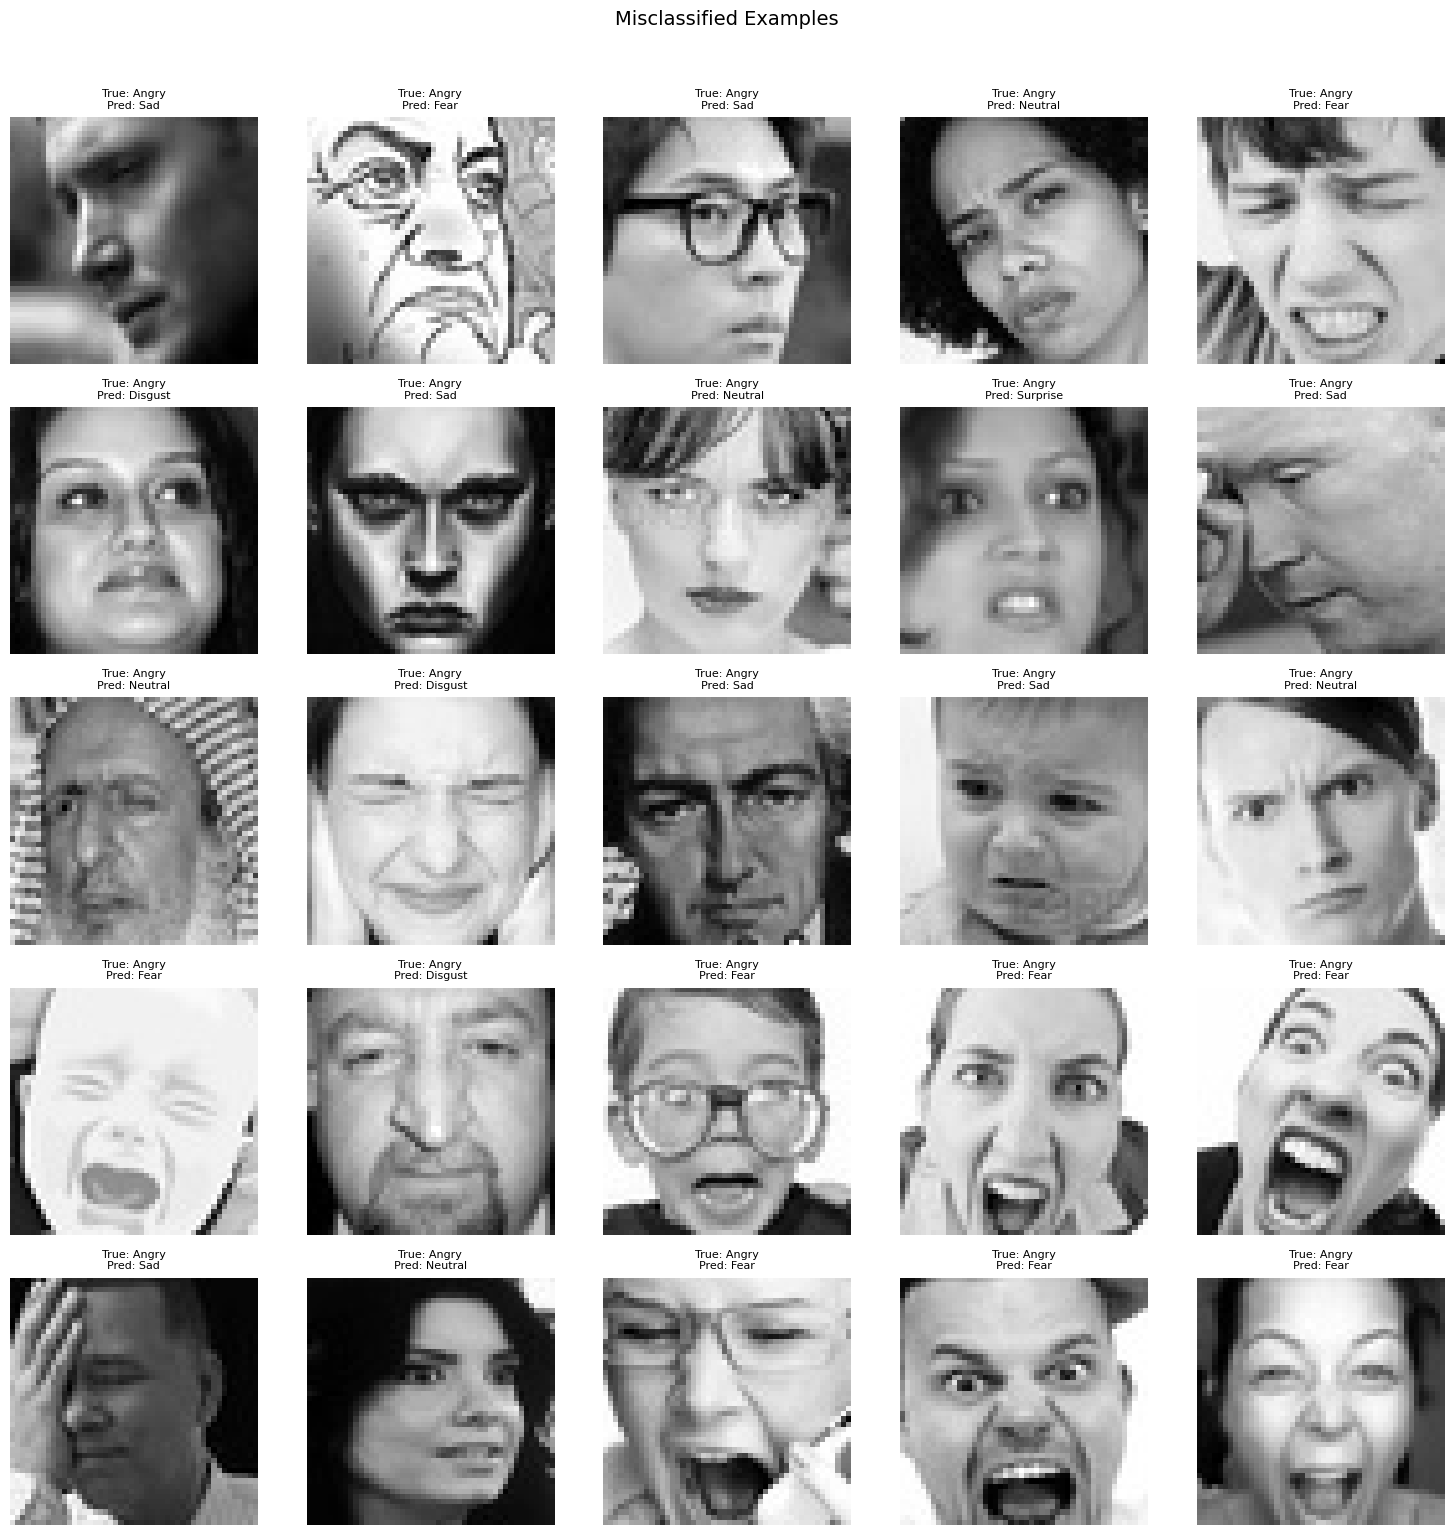

In [15]:
import numpy as np
import cv2

# ── Misclassified Images Visualization ──────────────────────────────────────

misclassified_indices = np.where(true_labels != pred_labels)[0]
print(f"Total misclassified: {len(misclassified_indices)} / {len(true_labels)}")

plt.figure(figsize=(15, 15))
for i, index in enumerate(misclassified_indices[:25]):
    plt.subplot(5, 5, i + 1)

    img_path = val_gen.filepaths[index]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48, 48))

    plt.imshow(img, cmap='gray')
    plt.title(f'True: {emotion_names[true_labels[index]]}\nPred: {emotion_names[pred_labels[index]]}',
              fontsize=8)
    plt.axis('off')

plt.suptitle('Misclassified Examples', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

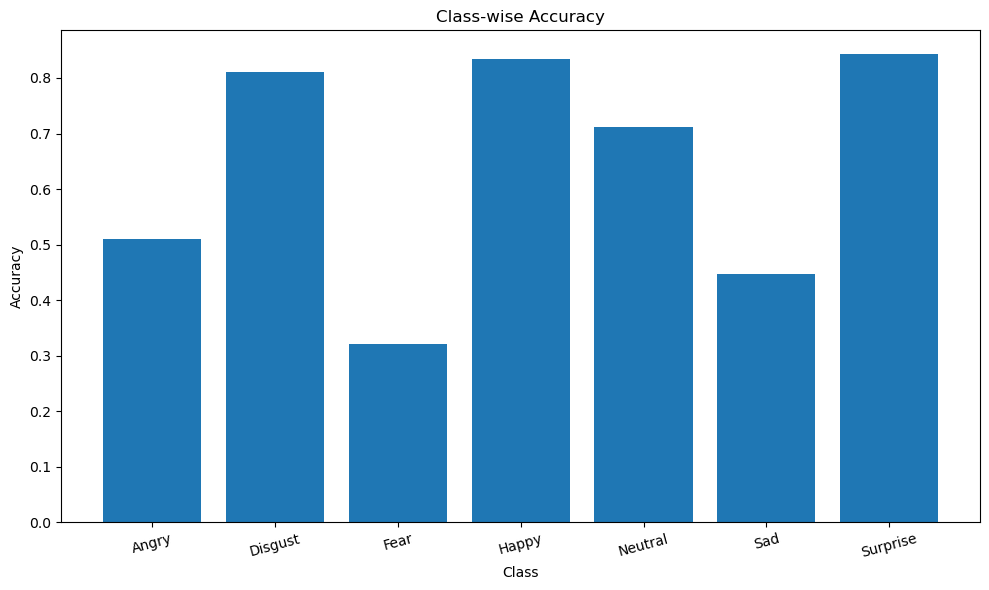

In [16]:
# ── Class-wise Accuracy ──────────────────────────────────────────────────────
emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

class_accuracies = []
for i, label in enumerate(emotion_names):
    class_indices = np.where(true_labels == i)[0]
    class_accuracy = np.mean(true_labels[class_indices] == pred_labels[class_indices])
    class_accuracies.append(class_accuracy)

# Plot class-wise accuracy
plt.figure(figsize=(10, 6))
plt.bar(emotion_names, class_accuracies)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Class-wise Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [13]:
# Quick final check – did we save the best weights?  
if os.path.exists(WEIGHTS_OUT):
    size_mb = os.path.getsize(WEIGHTS_OUT) / (1024 * 1024)
    print("Best model weights were saved successfully")
    print("Location:", WEIGHTS_OUT)
    print(f"File size: {size_mb:.1f} MB")
else:
    print("Warning: best weights file was not found – check ModelCheckpoint callback")

Best model weights were saved successfully
Location: C:\Users\Lfellous\Desktop\FER2013_results\emotion_model.weights.h5
File size: 21.8 MB


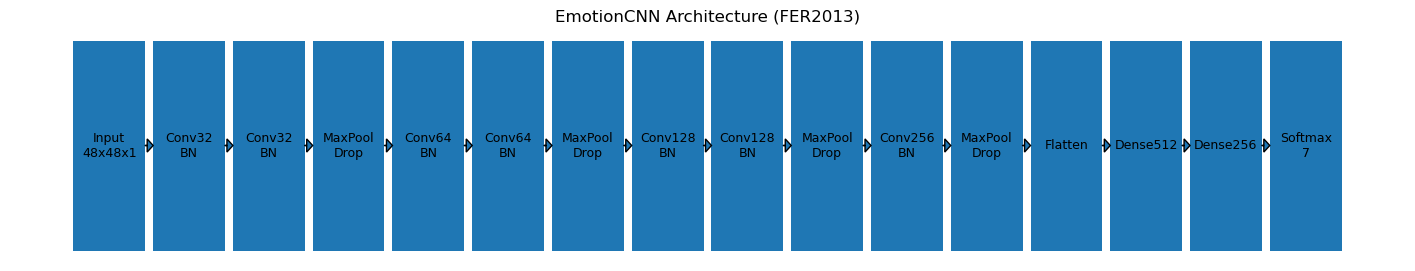

In [33]:
#to visualise the architecture (for presentation purposes)
layers = [
"Input\n48x48x1",

"Conv32\nBN",
"Conv32\nBN",
"MaxPool\nDrop",

"Conv64\nBN",
"Conv64\nBN",
"MaxPool\nDrop",

"Conv128\nBN",
"Conv128\nBN",
"MaxPool\nDrop",

"Conv256\nBN",
"MaxPool\nDrop",

"Flatten",
"Dense512",
"Dense256",
"Softmax\n7"
]

plt.figure(figsize=(18,3))

for i,l in enumerate(layers):
    plt.gca().add_patch(
        plt.Rectangle((i,0),0.9,0.8,fill=True)
    )
    plt.text(i+0.45,0.4,l,
             ha='center',va='center',fontsize=9)

    if i>0:
        plt.arrow(i-0.1,0.4,0.1,0,
                  head_width=0.05,length_includes_head=True)

plt.axis('off')
plt.title("EmotionCNN Architecture (FER2013)")
plt.show()